In [260]:
from google.colab import drive
import os

drive.mount('/content/drive/', force_remount=True)  # Force remount to update the mount point
!ln -s "/content/drive/MyDrive/padl_datasets" "/content/padl_datasets"  # Creating a symbolic link
os.chdir("/content/padl_datasets")

Mounted at /content/drive/


In [7]:
!pip install --upgrade --force-reinstall numpy==1.25.2
!pip install --upgrade --force-reinstall gensim==4.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 118.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blosc2 3.3.0 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.2 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 6.3 MB/s eta 0:00:00
ERROR: Operation cancelled by user
^C


# PADL coursework

In [186]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, accuracy_score, mean_absolute_error
from scipy.stats import mode

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt('datasets/PADL-Q11-train.csv', delimiter=',', skiprows=1)

# Split data into features and targets
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)

# Standardise X values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_val_scaled = scaler.transform(X_val)

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)
# X_val_poly = poly.transform(X_val_scaled)

# Linear regression model
model = LinearRegression()
model.fit(X_poly, y)
# y_pred = model.predict(X_val_poly)
# lin_r2 = r2_score(y_val, y_pred)


LinearRegression()

### B

In [ ]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt('datasets/PADL-Q12-train.csv', delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8)

# Standardise X values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_val_scaled)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print(f"Linear Regression Coefficients: {lr_model.coef_}")
print(f"Linear Regression R²: {r2_lr:.4f}")

# Now with regularised models
# Start off with declaring alpha values
alphas = [10, 1, 0.1, 0.01, 0.001, 1e-3, 1e-4]

# Initialize lists to store R² scores and coefficients for Ridge and Lasso
ridge_r2_scores = []
lasso_r2_scores = []
ridge_coeffs = []
lasso_coeffs = []

Linear Regression Coefficients: [17.55315215  8.88027268 14.45783128  0.75877445]
Linear Regression R²: 0.9566


### C

In [ ]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt('datasets/PADL-Q13-train.csv', delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Standardise features and apply pca
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train model with standardised data
lr_model_with_preprocessing = LinearRegression()
lr_model_with_preprocessing.fit(X_train_scaled, y_train)
y_pred_with_preprocessing = lr_model_with_preprocessing.predict(X_val_scaled)
r2_with_preprocessing = r2_score(y_val, y_pred_with_preprocessing)

# Display results
print(f"R² without preprocessing: {r2_lr:.4f}")
print(f"R² with preprocessing: {r2_with_preprocessing:.4f}")

R² without preprocessing: 0.9681
R² with preprocessing: 0.9681


## Q2

### A

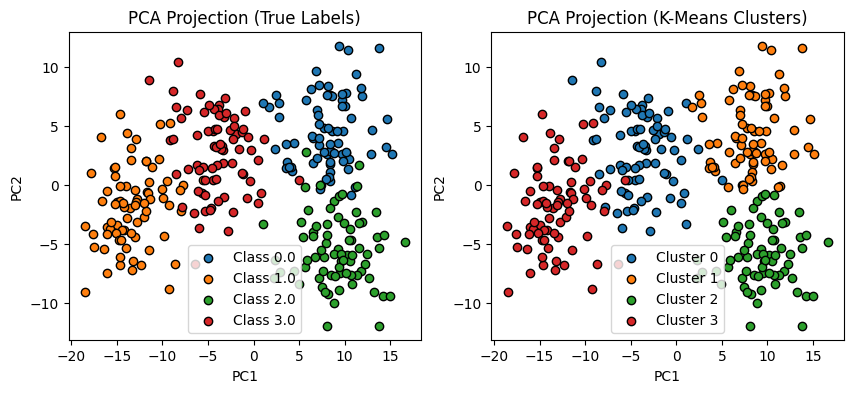

In [ ]:
# Load data from PADL-Q2.csv
data = np.loadtxt('datasets/PADL-Q2.csv', delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Might need standardising or normalisation

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create figure
plt.figure(figsize=(10,4))

# Plot PCA with true labels
plt.subplot(1, 2, 1)
for label in np.unique(Y):
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1], label=f"Class {label}", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (True Labels)")
plt.legend()

# Plot PCA projection with K-Means Clusters
plt.subplot(1, 2, 2)
for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans == cluster, 0], X_pca[Y_kmeans == cluster, 1], label=f"Cluster {cluster}", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (K-Means Clusters)")
plt.legend()

### B

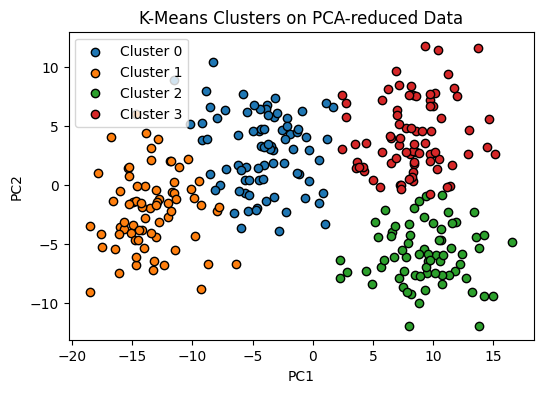

In [ ]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1], label=f"Cluster {cluster}", edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
with open('datasets/PADL-Q3.txt', 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
model = Word2Vec(sentences=sentences, sg=1)
word_embeddings = model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


Similarities with node 5:
Node 5 <-> Node 21: 0.1919
Node 5 <-> Node 22: 0.1497
Node 5 <-> Node 23: 0.2954
Node 5 <-> Node 24: 0.3021
Node 5 <-> Node 25: 0.2017
Node 5 <-> Node 26: 0.1908
Node 5 <-> Node 27: 0.2411
Node 5 <-> Node 28: 0.2294
Node 5 <-> Node 29: 0.1964
Node 5 <-> Node 30: 0.1898


### B

## Q4

### A

### B

In [257]:
# Get data from body_measurements.csv
data = np.genfromtxt('padl_datasets/body_measurements.csv', delimiter=',', skip_header=1, filling_values=np.nan)

# Filter out nan values
valid_rows = ~np.isnan(data).any(axis=1)
data_clean = data[valid_rows]

# Split data into features and labels
X = data_clean[:, :-1]
y = data_clean[:, -1]

# Split into train and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

## Look at removing features that arent important

# Preprocesing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# Model
class WaistPredictor(nn.Module):
    def __init__(self, input_size):
        super(WaistPredictor, self).__init__()
        self.model = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Layer 2
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            # Output layer
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

# Define model and training parameters
model = WaistPredictor(input_size=X_train_tensor.shape[1])
MAE_loss = nn.L1Loss()
Smooth_loss = nn.SmoothL1Loss()
optimiser = optim.AdamW(model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=15)

epochs = 1000
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)



Epoch 100, Train MAE: 28.80, Val MAE: 31.71
Epoch 200, Train MAE: 38.03, Val MAE: 31.70
Epoch 300, Train MAE: 34.21, Val MAE: 31.70
Epoch 400, Train MAE: 21.91, Val MAE: 31.70
Epoch 500, Train MAE: 40.72, Val MAE: 31.70
Epoch 600, Train MAE: 22.07, Val MAE: 31.70
Epoch 700, Train MAE: 29.52, Val MAE: 31.70
Epoch 800, Train MAE: 31.75, Val MAE: 31.70
Epoch 900, Train MAE: 47.68, Val MAE: 31.70
Epoch 1000, Train MAE: 33.49, Val MAE: 31.70
Final MAE on the validation set: 31.70


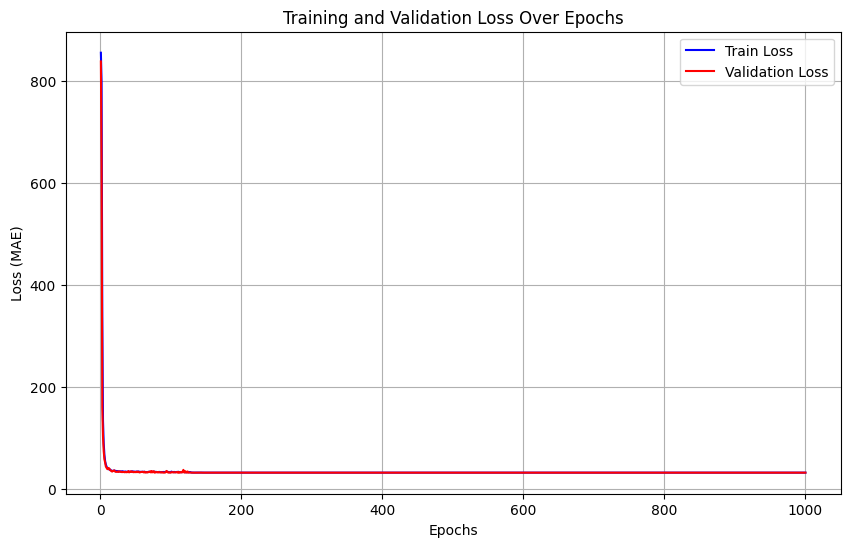

In [258]:
# Get rid of these
train_losses = []
val_losses = []

# Training loop
for epoch in range(epochs):
    total_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimiser.zero_grad()
        predictions = model(batch_X)
        loss = Smooth_loss(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = MAE_loss(val_preds, y_val_tensor).item()
        val_mae = mean_absolute_error(y_val, val_preds.numpy())  # Real-world MAE

    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Get rid of this
    if (epoch+1)%100 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {loss:.2f}, Val MAE: {val_loss:.2f}")

# Switch to evaluation mode
model.eval()
with torch.no_grad():
    # Get predictions on the scaled validation data
    y_val_pred = model(X_val_tensor).detach().numpy()

# Calculate the MAE in the original scale using sklearn's mean_absolute_error
final_mae = mean_absolute_error(y_val, y_val_pred)
print(f"Final MAE on the validation set: {final_mae:.2f}")

# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss", color='blue')
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

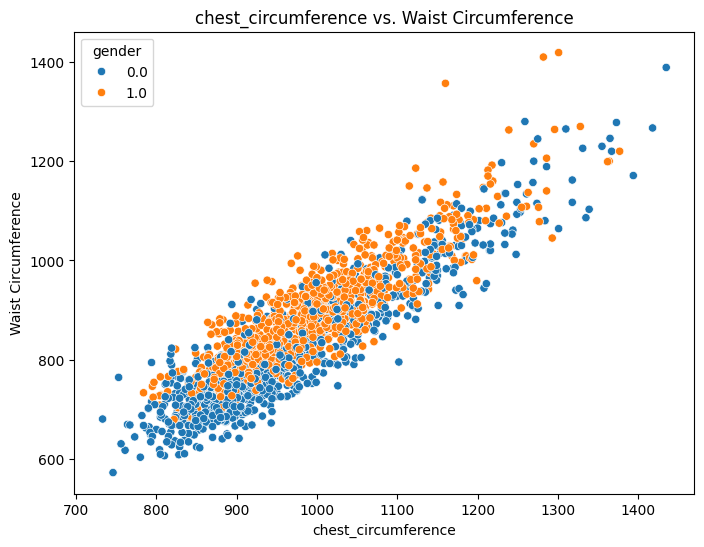

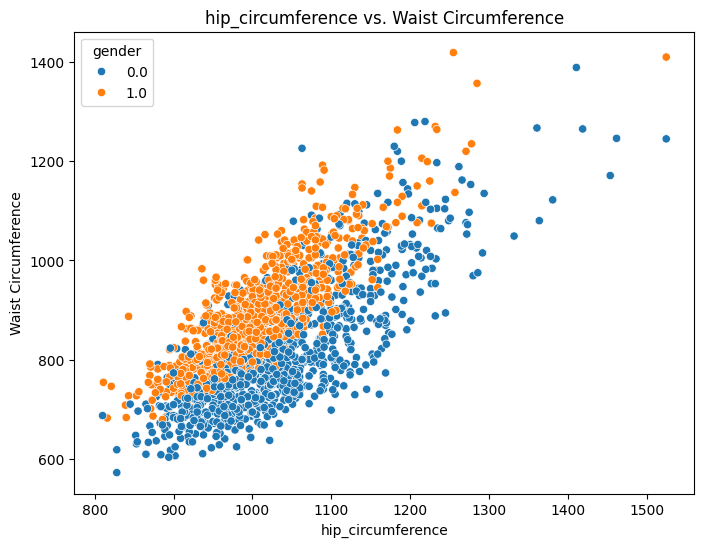

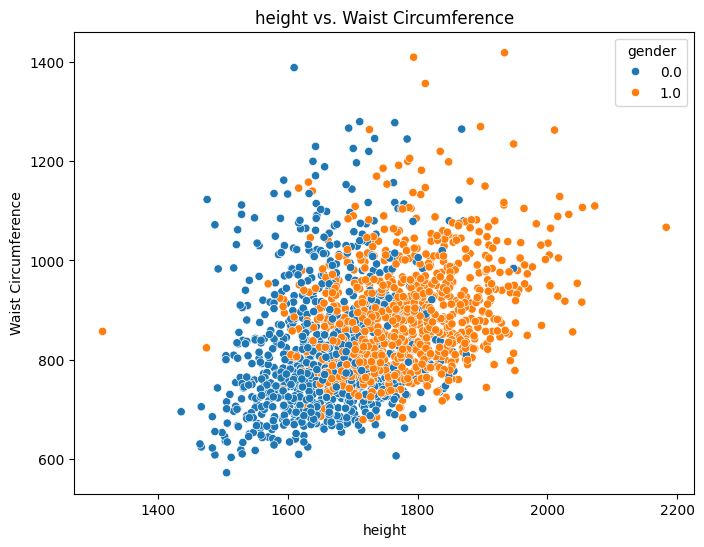

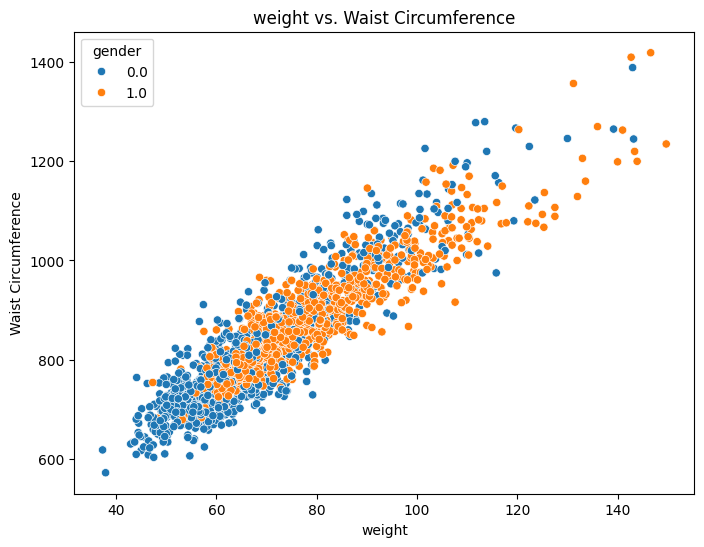

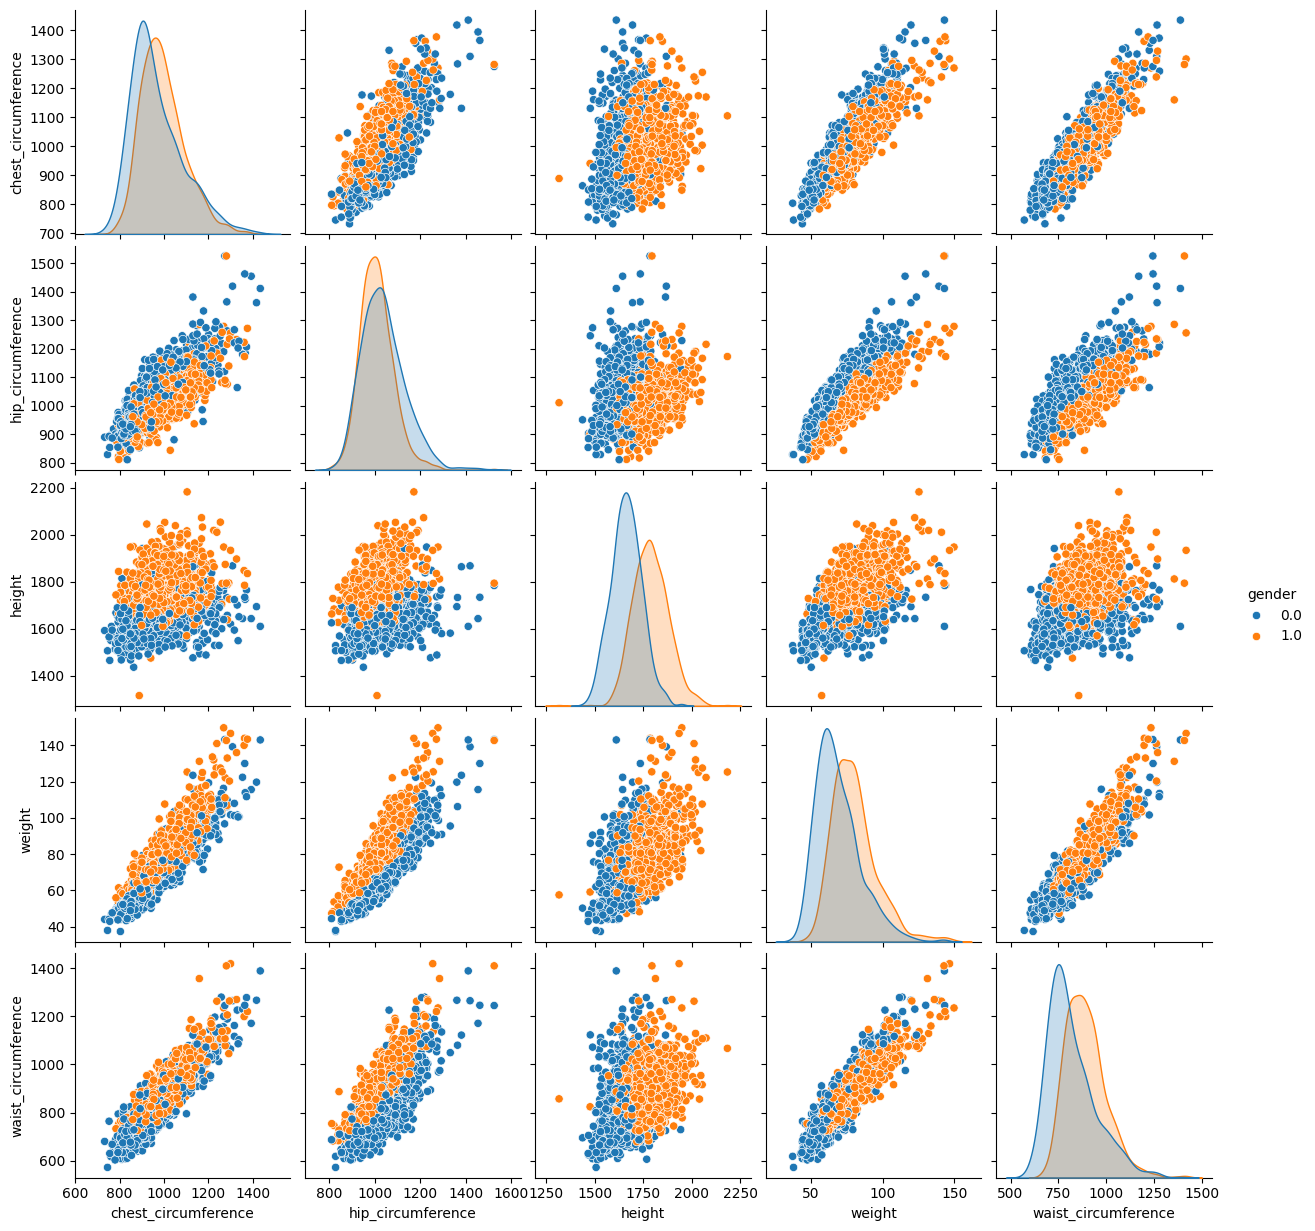

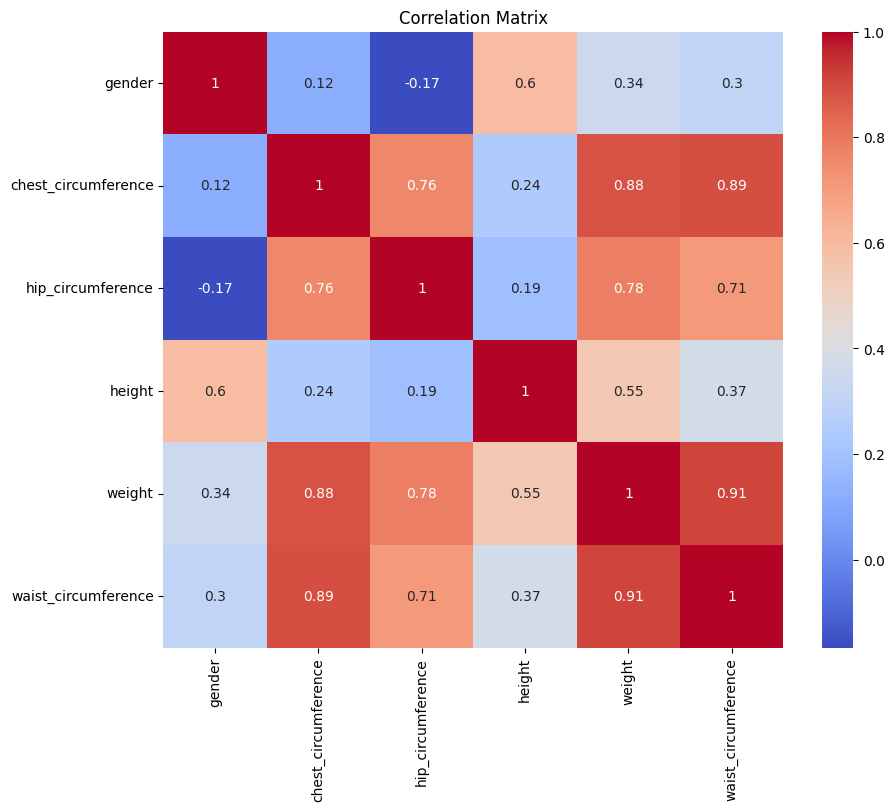

In [250]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is in a pandas DataFrame called 'data_df'
# with columns: 'gender', 'chest_circumference', 'hip_circumference',
# 'height', 'weight', 'waist_circumference'

# Scatter plots for individual features vs. waist circumference
features = ['chest_circumference', 'hip_circumference', 'height', 'weight']
for feature in features:
  plt.figure(figsize=(8, 6))
  sns.scatterplot(x=feature, y='waist_circumference', hue='gender', data=data_df)
  plt.title(f'{feature} vs. Waist Circumference')
  plt.xlabel(feature)
  plt.ylabel('Waist Circumference')
  plt.show()

# Pair plot for all features
sns.pairplot(data_df, hue='gender', vars=features + ['waist_circumference'])
plt.show()

# Correlation heatmap
corr_matrix = data_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Q5

### A

### B

In [ ]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),  # Replace x.view with nn.Flatten
            nn.Linear(128 * 32 * 32, 256),  # Adjust input size if needed
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.model(x)

## Q6

### A

### B

### C